In [7]:
from userValidator import validate_n, validate_mode, validate_sep_rep, validate_sijs
import torch
import numpy as np
from cal_simi_kernel import DenseSimilarity
from base_function import BaseFunction
from optimizers.optimizer_factory import OptimizerFactory

class FacilityLocation(BaseFunction):
    """
    Facility Location function implementation based on C++ version.
    
    The function value for a set X is: sum over all master items of their maximum similarity to any item in X.
    """

    def __init__(self, n, mode="dense", separate_rep=None, n_rep=None, sijs=None, 
                 data=None, data_rep=None, num_clusters=None, cluster_labels=None, 
                 metric="cosine", num_neighbors=None, create_dense_cpp_kernel_in_python=True, 
                 pybind_mode=None, partial=False, ground_set=None, separate_master=False):
        
        self.n = n
        self.n_rep = n_rep
        self.mode = mode
        self.metric = metric
        self.sijs = sijs
        self.data = data
        self.data_rep = data_rep
        self.num_neighbors = num_neighbors
        self.separate_rep = separate_rep
        self.clusters = None
        self.cluster_sijs = None
        self.cluster_map = None
        self.cluster_labels = cluster_labels
        self.num_clusters = num_clusters
        self.cpp_obj = None
        self.cpp_sijs = None
        self.cpp_ground_sub = None
        self.cpp_content = None
        self.effective_ground = None
        self.create_dense_kernel = create_dense_cpp_kernel_in_python
        self.optimizer = None
        
        # New parameters for proper ground set handling
        self.partial = partial
        self.ground_set = ground_set
        self.separate_master = separate_master
        
        # Memoization variables (similar to C++ version)
        self.similarity_with_nearest_in_effective_x = None
        self.memoization_initialized = False
        
        # Effective ground set - this is what getEffectiveGroundSet() should return
        self.effective_ground_set = None
        self.master_set = None
        self.n_master = None
        
        super().__init__()

        # Validate inputs
        validate_n(self.n)
        validate_mode(self.mode)
        validate_sep_rep(self.separate_rep, self.mode, self.n_rep)

        # Handle similarity kernel or data
        if self.sijs is not None:
            validate_sijs(type(self.sijs), self.mode, self.num_neighbors, self.separate_rep)
            if self.separate_rep == True:
                if self.data.shape[1] != self.data_rep.shape[1]:
                    raise Exception("ERROR: Data and Representation have different dimensions")
            if self.data is not None or self.data_rep is not None:
                print("WARNING: similarity kernel found. Provided data matrix will be ignored.")
        else:
            if self.data is None:
                raise Exception("ERROR: Data matrix not provided")
            
            # Convert numpy array to torch tensor if needed
            if isinstance(self.data, np.ndarray):
                self.data = torch.tensor(self.data, dtype=torch.float32)
            
            if self.create_dense_kernel == True and self.mode == "dense" and self.metric == "euclidean":
                self.sijs = DenseSimilarity.euclidean_distance(self.data)
            elif self.create_dense_kernel == True and self.mode == "dense" and self.metric == "cosine":
                self.sijs = DenseSimilarity.cosine_similarity(self.data)
            else:
                raise Exception("ERROR: Neither ground set data matrix nor similarity kernel provided")
        
        # Initialize effective ground set and master set (like C++ version)
        self._initialize_ground_sets()
        
        # Initialize memoization
        self._initialize_memoization()

    def _initialize_ground_sets(self):
        """Initialize effective ground set and master set like C++ version"""
        if self.partial and self.ground_set is not None:
            # Use provided ground set (partial mode)
            self.effective_ground_set = set(self.ground_set)
        else:
            # Create ground set with items 0 to n-1 (like C++ lines 28-32)
            self.effective_ground_set = set(range(self.n))
        
        # Determine master set
        if self.separate_master:
            # Master set is separate from ground set
            if self.sijs is not None:
                self.n_master = self.sijs.shape[0]
                self.master_set = set(range(self.n_master))
            else:
                raise Exception("ERROR: separate_master=True requires similarity kernel")
        else:
            # Master set is same as effective ground set (like C++ lines 88-90)
            self.n_master = len(self.effective_ground_set)
            self.master_set = self.effective_ground_set.copy()

    def _initialize_memoization(self):
        """Initialize memoization structures"""
        if self.sijs is not None and self.n_master is not None:
            self.similarity_with_nearest_in_effective_x = torch.zeros(self.n_master, dtype=torch.float32)
            self.memoization_initialized = True

    def maximize(self, optimizer, budget, stopIfZeroGain=False, stopIfNegativeGain=False, epsilon=None, 
                 verbose=False, show_progress=True, costs=None, costSensitiveGreedy=False):
        """Maximize the function using the optimizer"""
        optimizer_factory = OptimizerFactory()
        optimizer_obj = optimizer_factory.get_optimizer(optimizer)
        output = optimizer_obj.optimize(self, budget, stopIfZeroGain, stopIfNegativeGain, 
                                       epsilon, verbose, show_progress, costs, costSensitiveGreedy)
        return output

    def evaluate(self, evaluate_set):
        """
        Evaluate the facility location function on a set.
        Returns sum over all master items of their maximum similarity to any item in the set.
        """
        if not evaluate_set:
            return 0.0
        
        # Handle partial ground set (like C++ lines 286-292)
        if self.partial:
            # effectiveX = intersect(X, effectiveGroundSet)
            effective_x = evaluate_set & self.effective_ground_set
        else:
            effective_x = evaluate_set
        
        if not effective_x:
            return 0.0
        
        X_list = list(effective_x)
        X_tensor = torch.tensor(X_list, dtype=torch.long)
        
        # Get similarity scores for all master items with items in X
        # self.sijs shape: [n_master, n_ground]
        similarity_scores = self.sijs[:, X_tensor]  # Shape: [n_master, |X|]
        
        # For each master item, find maximum similarity to any item in X
        max_similarities = torch.max(similarity_scores, dim=1)[0]  # Shape: [n_master]
        
        # Sum over all master items
        return torch.sum(max_similarities).item()

    def marginalGain(self, X, element):
        """
        Compute marginal gain of adding element to set X.
        This is the difference in function value when element is added.
        """
        if element in X:
            return 0.0
        
        # Check if element is in effective ground set (like C++ lines 394-396)
        if element not in self.effective_ground_set:
            return 0.0
        
        # Simple implementation: evaluate difference
        current_val = self.evaluate(X)
        X_new = X | {element}  # Use set union
        new_val = self.evaluate(X_new)
        return new_val - current_val

    def maginalGainWithMemoization(self, X, element):
        """
        Compute marginal gain using memoization for efficiency.
        This is the key optimization that makes greedy algorithms fast.
        """
        if element in X:
            return 0.0
        
        # Check if element is in effective ground set
        if element not in self.effective_ground_set:
            return 0.0
        
        if not self.memoization_initialized:
            return self.marginalGain(X, element)
        
        gain = 0.0
        element_tensor = torch.tensor(element, dtype=torch.long)
        
        # For each master item, check if adding element improves the best similarity
        for master_idx in range(self.n_master):
            current_best = self.similarity_with_nearest_in_effective_x[master_idx]
            new_similarity = self.sijs[master_idx, element_tensor].item()
            
            if new_similarity > current_best:
                gain += (new_similarity - current_best)
        
        return gain

    def evalauteWithMemoization(self, evaluate_set):
        """
        Evaluate using pre-computed memoization.
        Assumes memoization is up-to-date for the given set.
        """
        if not self.memoization_initialized:
            return self.evaluate(evaluate_set)
        
        return torch.sum(self.similarity_with_nearest_in_effective_x).item()

    def updateMemoization(self, X, element):
        """
        Update memoization after adding element to set X.
        This is called after each greedy selection.
        """
        if not self.memoization_initialized:
            return
        
        element_tensor = torch.tensor(element, dtype=torch.long)
        
        # Update best similarities for all master items
        for master_idx in range(self.n_master):
            new_similarity = self.sijs[master_idx, element_tensor].item()
            if new_similarity > self.similarity_with_nearest_in_effective_x[master_idx]:
                self.similarity_with_nearest_in_effective_x[master_idx] = new_similarity

    def clearMemoization(self):
        """Clear all memoization data"""
        if self.memoization_initialized:
            self.similarity_with_nearest_in_effective_x.zero_()

    def setMemoization(self, X):
        """
        Set memoization for a given set X.
        This initializes memoization as if X was the current set.
        """
        self.clearMemoization()
        
        if not X:
            return
        
        # Update memoization for each element in X
        for element in X:
            self.updateMemoization(set(), element)

    def getEffectiveGroundSet(self):
        """
        Return the effective ground set (actual set, not size).
        This matches the C++ implementation.
        """
        return self.effective_ground_set.copy()  # Return a copy to prevent external modification




In [8]:
from sklearn.datasets import make_blobs
num_clusters = 10
cluster_std_dev = 4
points, cluster_ids, centers = make_blobs(n_samples=500, centers=num_clusters, 
                                          n_features=2, cluster_std=cluster_std_dev, center_box=(0,100), 
                                          return_centers=True, random_state=4)
data = list(map(tuple, points))
xs = [x[0] for x in data]
ys = [x[1] for x in data]

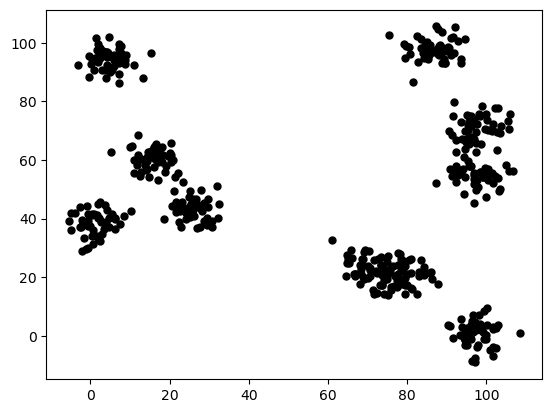

In [9]:
import matplotlib.pyplot as plt
plt.scatter(xs, ys, s=25, color='black', label="Images")

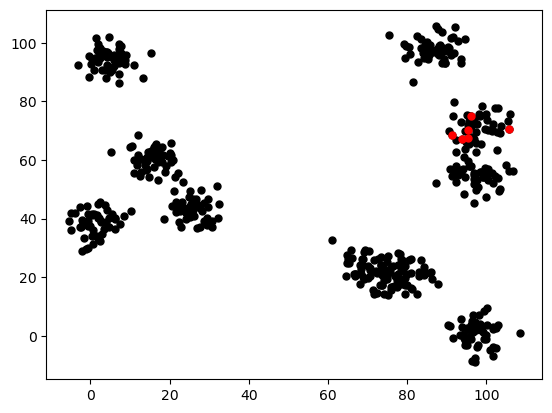

In [10]:
# get 6 data points belonging to cluster#1
import random
random.seed(1)
cluster1Indices = [index for index, val in enumerate(cluster_ids) if val == 1]
subset1 = random.sample(cluster1Indices, 6)
subset1xs = [xs[x] for x in subset1]
subset1ys = [ys[x] for x in subset1]
plt.scatter(xs, ys, s=25, color='black', label="Images")
plt.scatter(subset1xs, subset1ys, s=25, color='red', label="Subset1")
set1 = set(subset1[:-1])

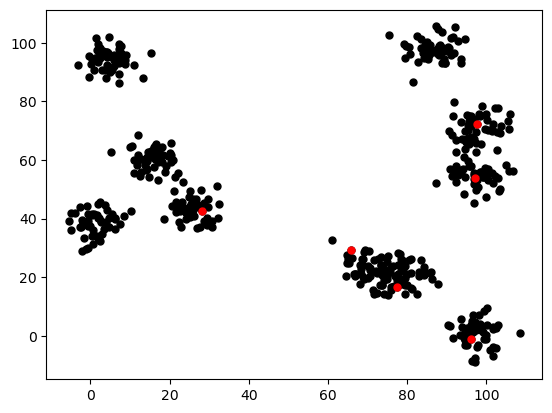

In [11]:
# get 6 data points belonging to different clusters
subset2 = []
for i in range(6):
    #find the index of first point that belongs to cluster i
    diverse_index = cluster_ids.tolist().index(i)
    subset2.append(diverse_index)
subset2xs = [xs[x] for x in subset2]
subset2ys = [ys[x] for x in subset2]
plt.scatter(xs, ys, s=25, color='black', label="Images")
plt.scatter(subset2xs, subset2ys, s=25, color='red', label="Subset2")
set2 = set(subset2[:-1])

In [12]:
import numpy as np
dataArray = np.array(data)

tensor([[1.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 1.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 1.0000e+00,  ..., 0.0000e+00, 0.0000e+00,
         6.5745e-04],
        ...,
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 1.0000e+00, 0.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 0.0000e+00,  ..., 0.0000e+00, 1.0000e+00,
         0.0000e+00],
        [0.0000e+00, 0.0000e+00, 6.5745e-04,  ..., 0.0000e+00, 0.0000e+00,
         1.0000e+00]])
Subset 1's FL value = 13.001643180847168
Subset 2's FL value = 12.063617706298828
Gain of adding another point (349) of same cluster to {418, 173, 81, 82, 62} = 1.1577262878417969
Gain of adding another point (5) of different cluster to {418, 173, 81, 82, 62} = 3.4608354568481445
Subset 1's Fast FL value = 13.001643180847168
Fast gain of adding another point (349) of same cluster to {418, 173, 81, 82,

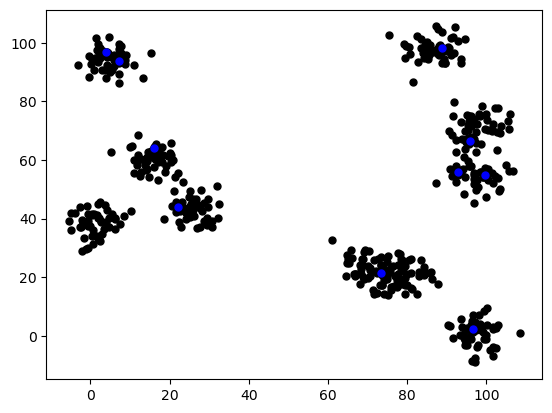

In [13]:
#start = time.process_time()
obj1 = FacilityLocation(n=500, mode="dense", data=dataArray, metric="euclidean")
print(obj1.sijs)
#print(f"Time taken by instantiation = {time.process_time() - start}")
print(f"Subset 1's FL value = {obj1.evaluate(set1)}")
print(f"Subset 2's FL value = {obj1.evaluate(set2)}")
print(f"Gain of adding another point ({subset1[-1]}) of same cluster to {set1} = {obj1.marginalGain(set1, subset1[-1])}")
print(f"Gain of adding another point ({subset2[-1]}) of different cluster to {set1} = {obj1.marginalGain(set1, subset2[-1])}")
obj1.setMemoization(set1)
print(f"Subset 1's Fast FL value = {obj1.evalauteWithMemoization(set1)}")
print(f"Fast gain of adding another point ({subset1[-1]}) of same cluster to {set1} = {obj1.maginalGainWithMemoization(set1, subset1[-1])}")
#start = time.process_time()
greedyList = obj1.maximize(budget=10,optimizer='NaiveGreedy', stopIfZeroGain=False, stopIfNegativeGain=False, verbose=False)
#print(f"Time taken by maximization = {time.process_time() - start}")
print(f"Greedy vector: {greedyList}")
greedyXs = [xs[x[0]] for x in greedyList]
greedyYs = [ys[x[0]] for x in greedyList]
plt.scatter(xs, ys, s=25, color='black', label="Images")
plt.scatter(greedyXs, greedyYs, s=25, color='blue', label="Greedy Set")